# Roxy projection module tutorial

This notebook demonstrates how to use the **Roxy projection module** on a
simulated classification dataset.

We will:

1. Generate a synthetic dataset with numeric features.
2. Infer feature types and scale numeric features.
3. Project the data using:
   - PCA (`PCAReducer` and the `project` convenience function),
   - t-SNE (`TSNEReducer` via `project`),
   - UMAP (`UMAPReducer` via `project`, if `umap-learn` is installed).
4. Visualise the resulting embeddings with scatter plots coloured by class labels.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from roxy.features import (
    infer_feature_kinds,
    ColumnScaler,
)

from roxy.projection import (
    project,
    PCAReducer,
    TSNEReducer,
    UMAPReducer,
)

## 1. Generate a simulated classification dataset

We use `sklearn.datasets.make_classification` to generate a dataset with
20 numeric features, of which only a subset is truly informative. This
is a simple stand-in for real feature matrices produced by Roxy.


In [2]:
X_num, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_repeated=0,
    n_clusters_per_class=2,
    class_sep=1.5,
    flip_y=0.02,
    random_state=42,
)

feature_names = [f"f{i}" for i in range(1, X_num.shape[1] + 1)]
df = pd.DataFrame(X_num, columns=feature_names)
target = pd.Series(y, name="label")

df.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
0,-2.732989,-1.014480,0.387198,1.942173,1.245226,1.461696,-1.741624,-0.681380,-1.340072,0.993782,1.029660,-1.244543,-0.608006,1.373914,0.938435,-0.848098,1.074600,0.967826,0.232868,0.432217
1,2.096275,0.592567,-0.921148,-1.541205,-2.663550,-1.791976,-1.332764,-0.488274,-2.704392,0.022631,1.688790,0.018017,-1.366858,-1.405563,-0.170736,0.861000,0.236902,0.633327,0.472630,-0.629885
2,1.707354,0.516144,-1.524263,-2.758279,4.740347,1.426264,-1.917331,-0.527994,-0.652528,-3.221016,1.392314,0.592330,-0.390409,0.395599,-5.222247,3.056818,-0.494973,1.353069,0.099314,-0.611177
3,2.507044,0.513614,0.027360,-3.701202,-0.573874,-2.457870,0.090324,0.654976,0.034714,-0.993863,0.466601,-1.217283,-0.892788,0.420192,-3.360184,1.588805,1.969170,0.810799,0.159463,-1.968504
4,-0.934076,0.203236,-1.014535,0.801837,-2.973453,-0.446222,1.095167,1.509131,-0.457633,0.508608,2.414597,1.159381,-0.779093,-0.430309,-0.557026,-3.444329,3.744131,0.605606,0.973102,0.185689


## 2. Infer feature types and scale numeric features

We classify each column into semantic kinds and then standardise the
numeric features using `ColumnScaler`. This step mirrors what you might
do on top of a `RoxyDataset` feature block.


In [3]:
kinds = infer_feature_kinds(df)
numeric_cols = [name for name, meta in kinds.items() if meta.kind.value == "numeric"]

numeric_cols

['f1',
 'f2',
 'f3',
 'f4',
 'f5',
 'f6',
 'f7',
 'f8',
 'f9',
 'f10',
 'f11',
 'f12',
 'f13',
 'f14',
 'f15',
 'f16',
 'f17',
 'f18',
 'f19',
 'f20']

In [4]:
scaler = ColumnScaler(strategy="standard", columns=numeric_cols)
X_scaled = scaler.fit_transform(df)

X_scaled.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
0,-1.447038,-0.924702,0.170648,1.216029,0.120724,0.640090,-0.236449,-0.599892,-1.275397,0.932548,0.143338,-1.228167,-0.569075,1.386103,0.822583,-0.764771,0.454021,1.055225,0.272223,0.421370
1,1.063270,0.606871,-0.318343,-0.513621,-1.196599,-0.855779,0.093275,-0.410077,-2.572835,-0.021725,0.474720,0.034277,-1.311440,-1.365018,0.280405,-0.043622,0.080732,0.699979,0.509946,-0.568434
2,0.861104,0.534037,-0.543756,-1.117952,1.298637,0.623800,-0.378147,-0.449120,-0.621558,-3.209001,0.325665,0.608537,-0.356205,0.417769,-2.188841,0.882897,-0.245402,1.464362,0.139804,-0.551000
3,1.276793,0.531626,0.036159,-1.586155,-0.492343,-1.161922,1.240921,0.713687,0.031994,-1.020553,-0.139743,-1.200909,-0.847669,0.442110,-1.278639,0.263473,0.852654,0.888458,0.199441,-1.815935
4,-0.511942,0.235824,-0.353247,0.649802,-1.301041,-0.237071,2.051273,1.553283,-0.436217,0.455806,0.839625,1.175537,-0.736445,-0.399714,0.091582,-1.860242,1.643602,0.670539,1.006162,0.191623


## 3. PCA projection

We first use PCA to obtain a 2D embedding. We demonstrate both:

- the `PCAReducer` class directly, and
- the `project` convenience function.


In [5]:
# Using the PCAReducer class explicitly
pca_reducer = PCAReducer(n_components=2, kwargs={"random_state": 42})
X_pca = pca_reducer.fit_transform(X_scaled)

X_pca[:5]

array([[-1.23044967, -2.13782324],
       [-0.52455839,  1.42927791],
       [ 1.56582634,  1.46573938],
       [ 0.85488076,  2.11560819],
       [-2.82003071,  0.04159347]])

In [6]:
# Using the project() helper for PCA
X_pca_proj = project(X_scaled, method="pca", n_components=2, random_state=42)

# Sanity check: both should have the same shape
X_pca.shape, X_pca_proj.shape

((500, 2), (500, 2))

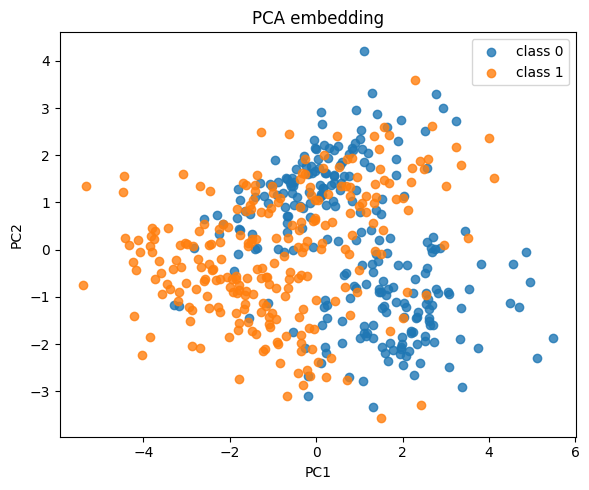

In [7]:
# Plot PCA embedding
plt.figure(figsize=(6, 5))
for label_value in np.unique(target):
    mask = target == label_value
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"class {label_value}",
        alpha=0.8,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA embedding")
plt.legend()
plt.tight_layout()
plt.show()

## 4. t-SNE projection

Next, we compute a 2D t-SNE embedding using the `project` helper. Note
that t-SNE is typically run only once per dataset and does not support a
reliable `transform` for new points in the scikit-learn implementation.


In [10]:
X_tsne = project(
    X_scaled,
    method="tsne",
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    random_state=42,
)

X_tsne[:5]

array([[  9.84688   ,  -0.56601757],
       [ -1.7714088 ,  11.094364  ],
       [-11.887882  ,   1.8356826 ],
       [ -6.65874   ,  12.21635   ],
       [ 21.361174  ,   2.309315  ]], dtype=float32)

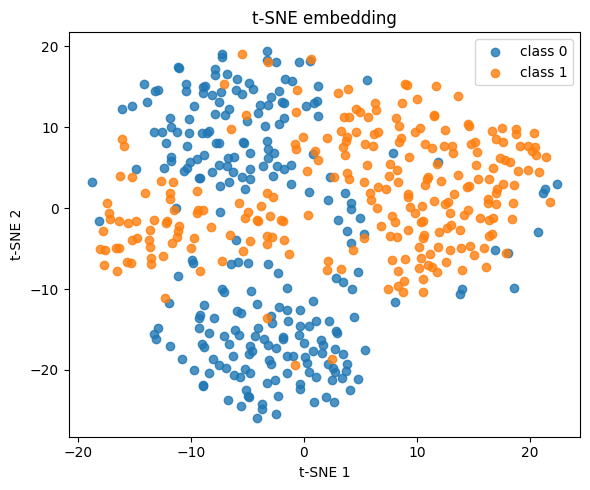

In [11]:
# Plot t-SNE embedding
plt.figure(figsize=(6, 5))
for label_value in np.unique(target):
    mask = target == label_value
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=f"class {label_value}",
        alpha=0.8,
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE embedding")
plt.legend()
plt.tight_layout()
plt.show()

## 5. UMAP projection (optional)

If `umap-learn` is installed in your environment, we can also compute a
2D UMAP embedding. If it is not installed, this section will print a
message and skip the UMAP computation.


In [9]:
try:
    X_umap = project(
        X_scaled,
        method="umap",
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=42,
    )

    # Plot UMAP embedding
    plt.figure(figsize=(6, 5))
    for label_value in np.unique(target):
        mask = target == label_value
        plt.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            label=f"class {label_value}",
            alpha=0.8,
        )

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("UMAP embedding")
    plt.legend()
    plt.tight_layout()
    plt.show()

except ImportError as e:
    print("UMAP not available:", e)
    print("Install 'umap-learn' to enable UMAPReducer.")

UMAP not available: UMAPReducer requires the 'umap-learn' package. Install it with `pip install umap-learn` to use this reducer.
Install 'umap-learn' to enable UMAPReducer.


## 6. Summary

In this notebook we have:

- Created a synthetic feature matrix and labels.
- Standardised numeric features with `ColumnScaler`.
- Projected the data into 2D using PCA, t-SNE and (optionally) UMAP
  through the Roxy projection module.
- Visualised the embeddings, colouring points by class.

These steps mirror how you would take feature blocks from a `RoxyDataset`
and obtain low-dimensional representations for exploratory analysis and
visualisation.
